# Test lc_index Extension

This notebook tests that the lc_index JupyterLab extension is properly installed and enabled.
- Verify Index tab is opened in left sidebar

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000
jupyter_work_dir = '../artifacts/jupyter-work'

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmp4_ecxbza


In [4]:
import importlib
import re

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251224-150127',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpkvgh61wa')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1766556087.776172 seconds


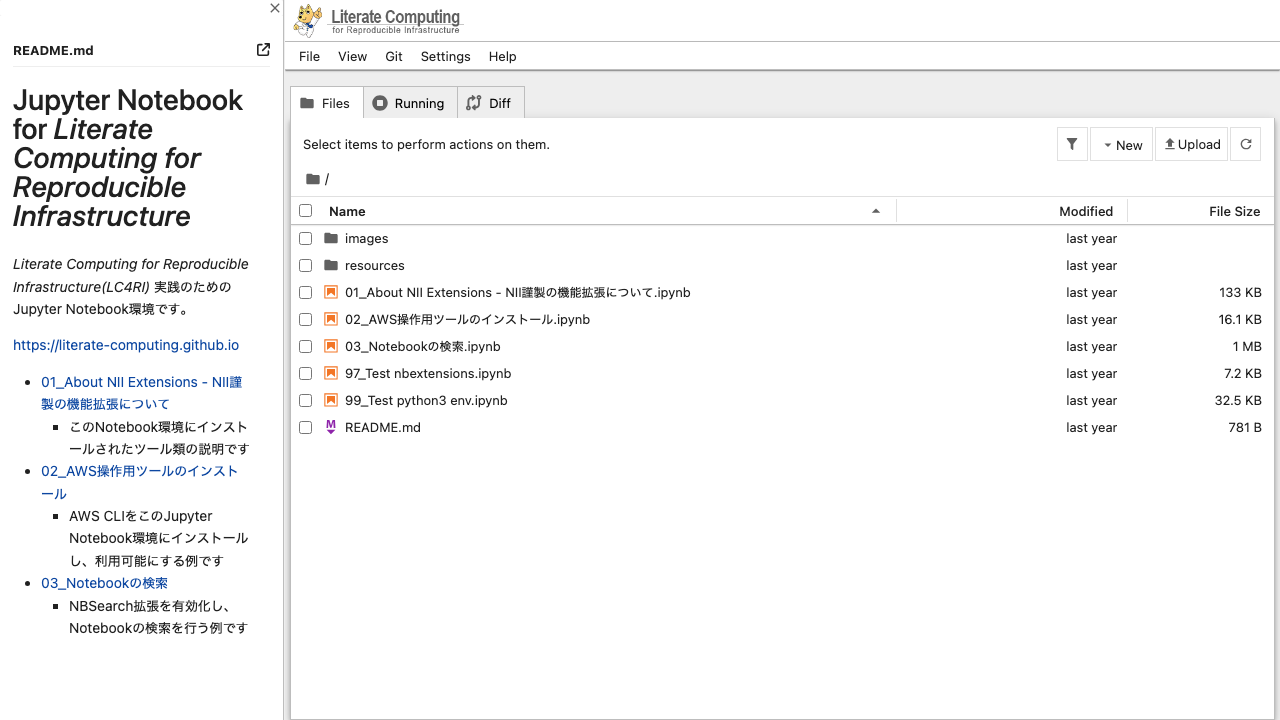

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Verify Index tab is opened in left sidebar

Start epoch: 1766556092.882828 seconds
✓ Index widget is automatically visible in left sidebar


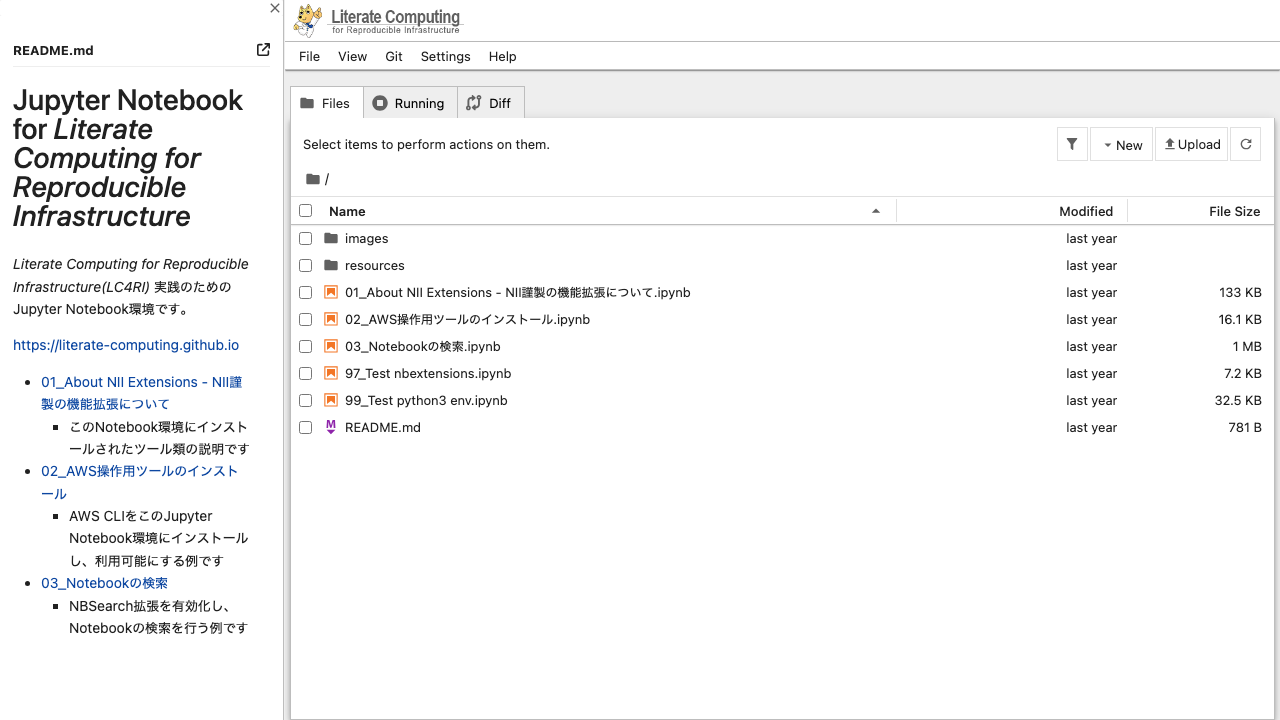

In [6]:
async def _step_readme_display(page):
    # Verify that Index widget is visible in left sidebar (it's automatically displayed in Notebook 7)
    index_widget = page.locator('#lc_index\\:index-left-widget\\:')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    # Verify it has the lc-index-widget class
    await expect(index_widget).to_have_class(re.compile(r'.*lc-index-widget.*'))
    
    print("✓ Index widget is automatically visible in left sidebar")

await run_pw(_step_readme_display)

## Cleanup

In [ ]:
await finish_pw_context()

In [8]:
!rm -rf {work_dir}